In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import catboost as cgb
except:
    %pip install -q catboost
    import catboost as cgb

In [2]:
!pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, nvidia-nccl-cu12, scipy
Required-by: TPOT


In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.calibration import CalibrationDisplay

import warnings

2026-03-21 15:45:43.325615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774107943.480958      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774107943.529697      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774107943.917719      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774107943.917754      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774107943.917757      24 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [7]:
display(train.head())
train.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

In [8]:
train[NUMS].describe()

,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000
mean,36.577258,65.866223,2494.377057
std,25.061922,31.067444,2353.916710
min,1.000000,18.250000,18.800000
25%,12.000000,29.900000,639.650000
50%,35.000000,74.100000,1433.650000
75%,62.000000,90.800000,4263.800000
max,72.000000,118.750000,8684.800000


In [9]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


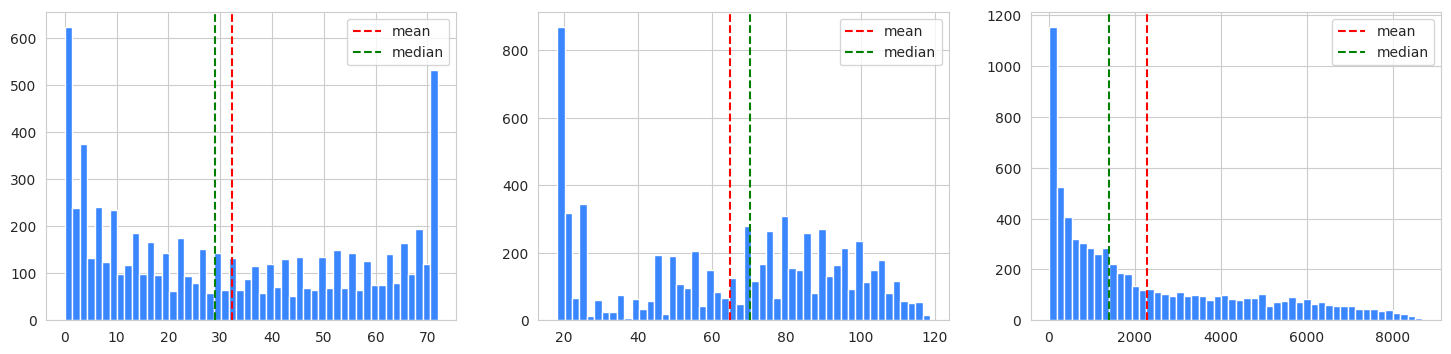

In [10]:
plt.figure(figsize=(18, 4))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.legend()
    
plt.show()

In [11]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


## FEATURE ENGINEERING

In [12]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [13]:
for col in ['TotalCharges']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)
        
print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_400, 
QUANTILE BINNING... TotalCharges_Qbin_1000, 
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 1
✅ TOTAL QUANTILE E_BINS: 1


In [14]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
            
    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)
        
    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 2
✅ TOTAL QUANTILE BINS: 2


In [15]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    # print()
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [12]: # 10, 50
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [12]: # 10, 50
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
EQUAL BINNING... tenure_bin_12, 
QUANTILE BINNING... tenure_Qbin_12, 
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 3         
✅ TOTAL QUANTILE BINS: 3         


In [16]:
ALL_ROUND_BINS = ROUNDS + E_BINS + Q_BINS

train[ALL_ROUND_BINS].nunique().sort_values()

tenure_round_-1               8
TotalCharges_round_-3        10
MonthlyCharges_round_-1      11
tenure_Qbin_12               11
tenure_bin_12                12
TotalCharges_round_-2        88
MonthlyCharges_bin_100      100
MonthlyCharges_round_0      102
TotalCharges_bin_400        396
MonthlyCharges_Qbin_500     433
TotalCharges_round_-1       846
TotalCharges_Qbin_1000      998
TotalCharges_round_1       5298
TotalCharges_round_0       5785
dtype: int64

In [17]:
LOW_100_UNIQUE = []

for col in ALL_ROUND_BINS:
    if train[col].nunique() < 100:
        LOW_100_UNIQUE.append(col)

print(f"Cats with ~100 unique: {len(LOW_100_UNIQUE)}")
print()
TOP_100_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_100_UNIQUE]
print(f"Cats with +100 unique: {len(TOP_100_UNIQUE)}")

Cats with ~100 unique: 6

Cats with +100 unique: 8


In [18]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[arithmetic].head()

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0
3,0.985856,70.699928,0.985857,1.014347,1.0
4,1.000000,70.449928,1.000001,1.000000,1.0


In [19]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [20]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)
    
# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [21]:
# INTER = []
# TOP_CATS = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'PaperlessBilling']

# for c1, c2 in tqdm(list(itertools.combinations(TOP_CATS+DIGITS, 2)), desc='Pairwise'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_CATS[:4], 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col] = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(TOP_PREDICTORS, OTHER_PREDICTORS)), desc='One-To-Many Pairwise'):
#     new_col = f"{c1}-|-{c2}"
#     train[new_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[new_col] = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[new_col] = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(new_col)

# print(f"TOTAL INTERACTION FEATURES: {len(INTER)}")

In [22]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [23]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [24]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE+ROUNDS+DIGITS,
    target=TARGET,
    aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
    # fill_nan=True,
)

TE_merging:   0%|          | 0/40 [00:00<?, ?it/s]

In [25]:
## -- DUPLICATE 'tunure' AS CATEGORICAL --
for df in [train, test, orig]:
    df['cat_tenure'] = df['tenure'].to_numpy()

In [26]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 132


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,tenure_bin_12,tenure_Qbin_12,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,OTE_tenure_mean,OTE_tenure_std,OTE_MonthlyCharges_mean,OTE_MonthlyCharges_std,OTE_TotalCharges_mean,OTE_TotalCharges_std,OTE_gender_mean,OTE_gender_std,OTE_SeniorCitizen_mean,OTE_SeniorCitizen_std,OTE_Partner_mean,OTE_Partner_std,OTE_Dependents_mean,OTE_Dependents_std,OTE_PhoneService_mean,OTE_PhoneService_std,OTE_MultipleLines_mean,OTE_MultipleLines_std,OTE_InternetService_mean,OTE_InternetService_std,OTE_OnlineSecurity_mean,OTE_OnlineSecurity_std,OTE_OnlineBackup_mean,OTE_OnlineBackup_std,OTE_DeviceProtection_mean,OTE_DeviceProtection_std,OTE_TechSupport_mean,OTE_TechSupport_std,OTE_StreamingTV_mean,OTE_StreamingTV_std,OTE_StreamingMovies_mean,OTE_StreamingMovies_std,OTE_Contract_mean,OTE_Contract_std,OTE_PaperlessBilling_mean,OTE_PaperlessBilling_std,OTE_PaymentMethod_mean,OTE_PaymentMethod_std,OTE_TotalCharges_round_-3_mean,OTE_TotalCharges_round_-3_std,OTE_TotalCharges_round_-2_mean,OTE_TotalCharges_round_-2_std,OTE_TotalCharges_round_-1_mean,OTE_TotalCharges_round_-1_std,OTE_TotalCharges_round_0_mean,OTE_TotalCharges_round_0_std,OTE_TotalCharges_round_1_mean,OTE_TotalCharges_round_1_std,OTE_MonthlyCharges_round_-1_mean,OTE_MonthlyCharges_round_-1_std,OTE_MonthlyCharges_round_0_mean,OTE_MonthlyCharges_round_0_std,OTE_tenure_round_-1_mean,OTE_tenure_round_-1_std,OTE_TotalCharges_digit_-3_mean,OTE_TotalCharges_digit_-3_std,OTE_TotalCharges_digit_-2_mean,OTE_TotalCharges_digit_-2_std,OTE_TotalCharges_digit_-1_mean,OTE_TotalCharges_digit_-1_std,OTE_TotalCharges_digit_0_mean,OTE_TotalCharges_digit_0_std,OTE_TotalCharges_digit_1_mean,OTE_TotalCharges_digit_1_std,OTE_TotalCharges_digit_2_mean,OTE_TotalCharges_digit_2_std,OTE_MonthlyCharges_digit_-2_mean,OTE_MonthlyCharges_digit_-2_std,OTE_MonthlyCharges_digit_-1_mean,OTE_MonthlyCharges_digit_-1_std,OTE_MonthlyCharges_digit_0_mean,OTE_MonthlyCharges_digit_0_std,OTE_MonthlyCharges_digit_1_mean,OTE_MonthlyCharges_digit_1_std,OTE_MonthlyCharges_digit_2_mean,OTE_MonthlyCharges_digit_2_std,OTE_tenure_digit_-1_mean,OTE_tenure_digit_-1_std,OTE_tenure_digit_0_mean,OTE_tenure_digit_0_std,cat_tenure
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,2000,1700,1650,1654,1653,1,6,5,3,8,5,75,538,60,60,0,6,0,1,0,41,133,30,2,9,4,5,0.036339,57.029308,1.053844,27.518303,841.0,0.208333,0.408966,1.000000,NaN,0.0,NaN,0.261603,0.43957,0.236062,0.424697,0.196649,0.397523,0.154502,0.361515,0.267096,0.442478,0.250442,0.433332,0.189591,0.392058,0.146112,0.353306,0.399288,0.489831,0.225021,0.417682,0.151663,0.358782,0.335231,0.472155,0.336804,0.472702,0.112695,0.316327,0.335651,0.472274,0.191067,0.393264,0.228833,0.420322,0.150442,0.359097,0.000,0.000000,0.0,0.0,0.0,0.0,0.154580,0.361849,0.150000,0.358870,0.214634,0.410903,0.207883,0.405949,0.202147,0.401961,0.279770,0.449209,0.233524,0.423376,0.261976,0.440039,0.262375,0.439992,0.262755,0.440166,0.194495,0.396175,0.235829,0.424665,0.256376,0.436925,0.268293,0.443139,0.230971,0.421731,0.231054,0.421897,29
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.

# ML TRAINING

In [27]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):

    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")

    start = time()
    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} | ", end='')

        ## -- Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # # -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features = BASE,
        #     aggs = ['count'],# 'std']# 'nunique']#'median']#,], 'max'
        #     # fill_nan=True,
        # )

        ## -- TE Opt1. -> Using CUSTOM -- LOW_100_UNIQUE, TOP_100_UNIQUE
        TE = TargetEncoder(TOP_100_UNIQUE, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, pd.Series(y_train))
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        combined = pd.concat([X_train, X_val, X_test])
        all_categorical = cats+LOW_100_UNIQUE
        for c in all_categorical:
            combined[c] = combined[c].astype('str')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        print(f'X_train shape: {X_train.shape}')

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_val, label=y_val, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=50_000,
            eval_set=dval,
            early_stopping_rounds=300,
            verbose=1000,
        )
        
        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1].ravel()
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1].ravel()

        # Calculate and print fold score
        fold_auc = roc_auc_score(y_val.to_numpy(), oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f'{YELLOW} • FOLD {idx+1} AUC: {fold_auc:.6f}{RESET}')

        # Clean up memory
        del X_train, X_val, y_train, y_val, X_test, dtrain, dval, dtest
        gc.collect()

    # Average the test predictions
    test_preds /= kf.n_splits
    
    # Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • FOLD {i+1} AUC: {score:.6f}")

    # Calculate and print the final out-of-fold AUC
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)
    
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [28]:
version_name = 'catV2_'

all_model_predictions = {}

ALL_CATS = CATS+DIGITS+['cat_tenure']

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [29]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = 'Trial_'
# COMPILER = []

# OUT_LOOP = [0.5, 1.0]
# INN_LOOP = [4.0]
# p_name   = ['BT', 'L1']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': outer,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.05,
#             # 'depth': 6,
#             # 'l2_leaf_reg': REGULATE,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=CATS+DIGITS+['cat_tenure'],
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [30]:
# all_model_scores = {}

# for comp in COMPILER:
#     for model_name, item in comp.items():
#         for key, value in item.items():
#             if key == 'score':
#                 # print(k, y)
#                 all_model_scores[model_name] = value

# plt.figure(figsize=(20, 6))
# # pd.Series(all_model_scores).plot(marker='o')
# sns.lineplot(all_model_scores, marker='o')
# plt.title('CATBoost Scores', fontweight='semibold')

# for i, score in enumerate(all_model_scores.values()):
#     plt.text(float(i), score-5e-8, score, ha='right', va='baseline')

# plt.tick_params('x', rotation=45, reset=True)
# plt.show()

In [31]:
## =========== BOOSTING TYPE: PLAIN ==============
LR = 0.01
REGULATE = 3.0


PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_strength': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    # 'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}bayes_"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ==================================================== 

# M_NAME = f"{version_name}MVS_"

# PARAMS = {
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': LR,
#     # 'depth': 6,
#     'l2_leaf_reg': REGULATE,
#     'random_state': SEED,
#     'verbose': 0,
#     'allow_writing_files': False,
#     'thread_count': os.cpu_count(),
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = M_NAME + str(LR).split('.')[1] + '_' +  str(SEED)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS
# )

# ## ==================================================== 

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Depthwise',
    # ---------------------------------
    'bootstrap_type': 'Bernoulli',
    'subsample': 0.8, # auto 0.66 for 'Bernoulli'
    # 'colsample_bylevel': 0.7,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    # 'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}bern_"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

## ==================================================== 

LEAVES = 64

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Lossguide',
    # ---------------------------------
    'max_leaves': LEAVES,
    # 'min_data_in_leaf': 2,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    # 'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}loss_"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)


==================== Starting Cross-Validation for catV2_bayes_ ====================

***** FOLD 1/10 | X_train shape: (534774, 132)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8999287	best: 0.8999287 (0)	total: 196ms	remaining: 2h 43m 7s
1000:	test: 0.9173486	best: 0.9173486 (1000)	total: 1m 31s	remaining: 1h 14m 18s
2000:	test: 0.9183182	best: 0.9183182 (2000)	total: 3m 3s	remaining: 1h 13m 15s
3000:	test: 0.9187622	best: 0.9187622 (3000)	total: 4m 35s	remaining: 1h 11m 48s
4000:	test: 0.9189998	best: 0.9189998 (4000)	total: 6m 7s	remaining: 1h 10m 19s
5000:	test: 0.9191508	best: 0.9191508 (4999)	total: 7m 40s	remaining: 1h 8m 59s
6000:	test: 0.9192725	best: 0.9192727 (5981)	total: 9m 13s	remaining: 1h 7m 34s
7000:	test: 0.9193628	best: 0.9193630 (6999)	total: 10m 46s	remaining: 1h 6m 10s
8000:	test: 0.9194291	best: 0.9194291 (8000)	total: 12m 21s	remaining: 1h 4m 49s
9000:	test: 0.9194834	best: 0.9194835 (8957)	total: 13m 55s	remaining: 1h 3m 25s
10000:	test: 0.9195288	best: 0.9195290 (9996)	total: 15m 30s	remaining: 1h 2m 1s
11000:	test: 0.9195631	best: 0.9195659 (10931)	total: 17m 5s	remaining: 1h 35s
12000:	test: 0.9195783	best: 0.9195834 (11

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8995154	best: 0.8995154 (0)	total: 118ms	remaining: 1h 38m 40s
1000:	test: 0.9169128	best: 0.9169128 (1000)	total: 1m 33s	remaining: 1h 16m 6s
2000:	test: 0.9177257	best: 0.9177257 (2000)	total: 3m 5s	remaining: 1h 14m 8s
3000:	test: 0.9181178	best: 0.9181178 (3000)	total: 4m 37s	remaining: 1h 12m 29s
4000:	test: 0.9183375	best: 0.9183381 (3999)	total: 6m 10s	remaining: 1h 11m
5000:	test: 0.9184806	best: 0.9184806 (5000)	total: 7m 43s	remaining: 1h 9m 32s
6000:	test: 0.9185977	best: 0.9185981 (5997)	total: 9m 16s	remaining: 1h 8m 3s
7000:	test: 0.9186684	best: 0.9186692 (6900)	total: 10m 50s	remaining: 1h 6m 33s
8000:	test: 0.9187412	best: 0.9187421 (7996)	total: 12m 24s	remaining: 1h 5m 6s
9000:	test: 0.9187857	best: 0.9187863 (8995)	total: 13m 58s	remaining: 1h 3m 40s
10000:	test: 0.9188352	best: 0.9188361 (9994)	total: 15m 33s	remaining: 1h 2m 14s
11000:	test: 0.9188556	best: 0.9188591 (10983)	total: 17m 8s	remaining: 1h 47s
12000:	test: 0.9188837	best: 0.9188846 (11993)	

...

0:	test: 0.9072503	best: 0.9072503 (0)	total: 75.7ms	remaining: 1h 3m 6s
1000:	test: 0.9183070	best: 0.9183074 (997)	total: 57.8s	remaining: 47m 7s
2000:	test: 0.9187863	best: 0.9187874 (1993)	total: 1m 58s	remaining: 47m 18s
3000:	test: 0.9189636	best: 0.9189651 (2989)	total: 2m 49s	remaining: 44m 17s
bestTest = 0.9189966917
bestIteration = 3272
Shrink model to first 3273 iterations.
 • FOLD 8 AUC: 0.918997

***** FOLD 9/10 | X_train shape: (534775, 132)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9059287	best: 0.9059287 (0)	total: 74.5ms	remaining: 1h 2m 3s
1000:	test: 0.9175349	best: 0.9175349 (999)	total: 54.9s	remaining: 44m 49s
2000:	test: 0.9179625	best: 0.9179625 (2000)	total: 1m 54s	remaining: 45m 47s
3000:	test: 0.9181549	best: 0.9181560 (2989)	total: 2m 51s	remaining: 44m 48s
bestTest = 0.9182142019
bestIteration = 3508
Shrink model to first 3509 iterations.
 • FOLD 9 AUC: 0.918214

***** FOLD 10/10 | X_train shape: (534775, 132)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9051834	best: 0.9051834 (0)	total: 74.1ms	remaining: 1h 1m 46s
1000:	test: 0.9161395	best: 0.9161395 (1000)	total: 59.5s	remaining: 48m 34s
2000:	test: 0.9165739	best: 0.9165758 (1988)	total: 1m 55s	remaining: 46m 5s
bestTest = 0.916592598
bestIteration = 2254
Shrink model to first 2255 iterations.
 • FOLD 10 AUC: 0.916593

Cross-Validation Results for catV2_loss_
 • FOLD 1 AUC: 0.919338
 • FOLD 2 AUC: 0.918408
 • FOLD 3 AUC: 0.920359
 • FOLD 4 AUC: 0.918203
 • FOLD 5 AUC: 0.918245
 • FOLD 6 AUC: 0.919155
 • FOLD 7 AUC: 0.921005
 • FOLD 8 AUC: 0.918997
 • FOLD 9 AUC: 0.918214
 • FOLD 10 AUC: 0.916593
-------------------------------------------------|
Overall AUC: 0.918846
Average AUC: 0.918852 ± 0.001173
-------------------------------------------------|
40.96 mins



In [32]:
## =========== BOOSTING TYPE: ORDERED ==============

PARAMS = {
    'boosting_type': 'Ordered',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    # 'l2_leaf_reg': REGULATE,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

n = f"{version_name}ord_bayes_"

all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)


==================== Starting Cross-Validation for catV2_ord_bayes_ ====================

***** FOLD 1/10 | X_train shape: (534774, 132)


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8999287	best: 0.8999287 (0)	total: 225ms	remaining: 3h 7m 21s
1000:	test: 0.9174023	best: 0.9174023 (1000)	total: 2m 31s	remaining: 2h 3m 57s
2000:	test: 0.9182827	best: 0.9182827 (2000)	total: 4m 59s	remaining: 1h 59m 51s
3000:	test: 0.9186125	best: 0.9186129 (2998)	total: 7m 23s	remaining: 1h 55m 46s
4000:	test: 0.9187518	best: 0.9187518 (3996)	total: 9m 42s	remaining: 1h 51m 42s
5000:	test: 0.9188639	best: 0.9188644 (4996)	total: 12m 2s	remaining: 1h 48m 21s
6000:	test: 0.9189292	best: 0.9189292 (5980)	total: 14m 22s	remaining: 1h 45m 22s
7000:	test: 0.9189871	best: 0.9189873 (6996)	total: 16m 42s	remaining: 1h 42m 39s
8000:	test: 0.9190344	best: 0.9190346 (7995)	total: 19m 2s	remaining: 1h 39m 58s
9000:	test: 0.9190650	best: 0.9190651 (8976)	total: 21m 20s	remaining: 1h 37m 14s
10000:	test: 0.9190960	best: 0.9190963 (9970)	total: 23m 39s	remaining: 1h 34m 37s
11000:	test: 0.9191183	best: 0.9191185 (10986)	total: 25m 58s	remaining: 1h 32m 4s
12000:	test: 0.9191393	best: 0

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8995154	best: 0.8995154 (0)	total: 226ms	remaining: 3h 8m 5s
1000:	test: 0.9169405	best: 0.9169405 (1000)	total: 2m 30s	remaining: 2h 3m 4s
2000:	test: 0.9177022	best: 0.9177022 (1999)	total: 4m 59s	remaining: 1h 59m 40s
3000:	test: 0.9179721	best: 0.9179721 (3000)	total: 7m 22s	remaining: 1h 55m 35s
4000:	test: 0.9181230	best: 0.9181230 (4000)	total: 9m 43s	remaining: 1h 51m 42s
5000:	test: 0.9182162	best: 0.9182162 (4998)	total: 12m 2s	remaining: 1h 48m 19s
6000:	test: 0.9183062	best: 0.9183062 (5995)	total: 14m 22s	remaining: 1h 45m 23s
7000:	test: 0.9183511	best: 0.9183511 (6999)	total: 16m 38s	remaining: 1h 42m 12s
8000:	test: 0.9183903	best: 0.9183903 (7991)	total: 18m 54s	remaining: 1h 39m 17s
9000:	test: 0.9184160	best: 0.9184165 (8929)	total: 21m 10s	remaining: 1h 36m 25s
10000:	test: 0.9184381	best: 0.9184388 (9989)	total: 23m 26s	remaining: 1h 33m 46s
11000:	test: 0.9184719	best: 0.9184719 (10982)	total: 25m 44s	remaining: 1h 31m 16s
12000:	test: 0.9185014	best: 0

...

0:	test: 0.9015725	best: 0.9015725 (0)	total: 211ms	remaining: 2h 55m 47s
1000:	test: 0.9176719	best: 0.9176719 (1000)	total: 2m 31s	remaining: 2h 3m 45s
2000:	test: 0.9184316	best: 0.9184316 (2000)	total: 4m 59s	remaining: 1h 59m 49s
3000:	test: 0.9187068	best: 0.9187068 (3000)	total: 7m 21s	remaining: 1h 55m 20s
4000:	test: 0.9188669	best: 0.9188669 (3994)	total: 9m 43s	remaining: 1h 51m 49s
5000:	test: 0.9189559	best: 0.9189560 (4999)	total: 12m 3s	remaining: 1h 48m 29s
6000:	test: 0.9190246	best: 0.9190246 (5995)	total: 14m 23s	remaining: 1h 45m 31s
7000:	test: 0.9190724	best: 0.9190724 (6999)	total: 16m 46s	remaining: 1h 42m 59s
8000:	test: 0.9191085	best: 0.9191085 (7999)	total: 19m 6s	remaining: 1h 40m 18s
9000:	test: 0.9191483	best: 0.9191483 (9000)	total: 21m 28s	remaining: 1h 37m 49s
10000:	test: 0.9191791	best: 0.9191793 (9995)	total: 23m 48s	remaining: 1h 35m 13s
11000:	test: 0.9192007	best: 0.9192020 (10941)	total: 26m 8s	remaining: 1h 32m 41s
12000:	test: 0.9192262	best: 

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8988398	best: 0.8988398 (0)	total: 222ms	remaining: 3h 5m 16s
1000:	test: 0.9167343	best: 0.9167343 (1000)	total: 2m 30s	remaining: 2h 2m 49s
2000:	test: 0.9174380	best: 0.9174380 (2000)	total: 4m 56s	remaining: 1h 58m 33s
3000:	test: 0.9176269	best: 0.9176270 (2998)	total: 7m 15s	remaining: 1h 53m 38s
4000:	test: 0.9177634	best: 0.9177634 (3998)	total: 9m 34s	remaining: 1h 50m 5s
5000:	test: 0.9178466	best: 0.9178466 (4998)	total: 11m 50s	remaining: 1h 46m 36s
6000:	test: 0.9179236	best: 0.9179236 (6000)	total: 14m 8s	remaining: 1h 43m 41s
7000:	test: 0.9180258	best: 0.9180258 (7000)	total: 16m 30s	remaining: 1h 41m 20s
8000:	test: 0.9181001	best: 0.9181005 (7990)	total: 18m 52s	remaining: 1h 39m 6s
9000:	test: 0.9181457	best: 0.9181457 (8999)	total: 21m 11s	remaining: 1h 36m 31s
10000:	test: 0.9181935	best: 0.9181936 (9991)	total: 23m 33s	remaining: 1h 34m 12s
11000:	test: 0.9182227	best: 0.9182227 (11000)	total: 25m 51s	remaining: 1h 31m 39s
12000:	test: 0.9182484	best: 0

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8974434	best: 0.8974434 (0)	total: 222ms	remaining: 3h 5m 4s
1000:	test: 0.9152983	best: 0.9152983 (1000)	total: 2m 31s	remaining: 2h 3m 19s
2000:	test: 0.9159760	best: 0.9159760 (2000)	total: 4m 58s	remaining: 1h 59m 12s
3000:	test: 0.9162412	best: 0.9162415 (2996)	total: 7m 21s	remaining: 1h 55m 13s
4000:	test: 0.9163966	best: 0.9163967 (3997)	total: 9m 44s	remaining: 1h 51m 58s
5000:	test: 0.9164777	best: 0.9164777 (5000)	total: 12m 5s	remaining: 1h 48m 47s
6000:	test: 0.9165461	best: 0.9165462 (5995)	total: 14m 26s	remaining: 1h 45m 54s
7000:	test: 0.9166105	best: 0.9166108 (6995)	total: 16m 48s	remaining: 1h 43m 11s
8000:	test: 0.9166589	best: 0.9166591 (7999)	total: 19m 11s	remaining: 1h 40m 42s
9000:	test: 0.9167058	best: 0.9167058 (8988)	total: 21m 33s	remaining: 1h 38m 11s
10000:	test: 0.9167235	best: 0.9167249 (9968)	total: 23m 55s	remaining: 1h 35m 41s
11000:	test: 0.9167395	best: 0.9167396 (10935)	total: 26m 13s	remaining: 1h 32m 58s
12000:	test: 0.9167484	best: 

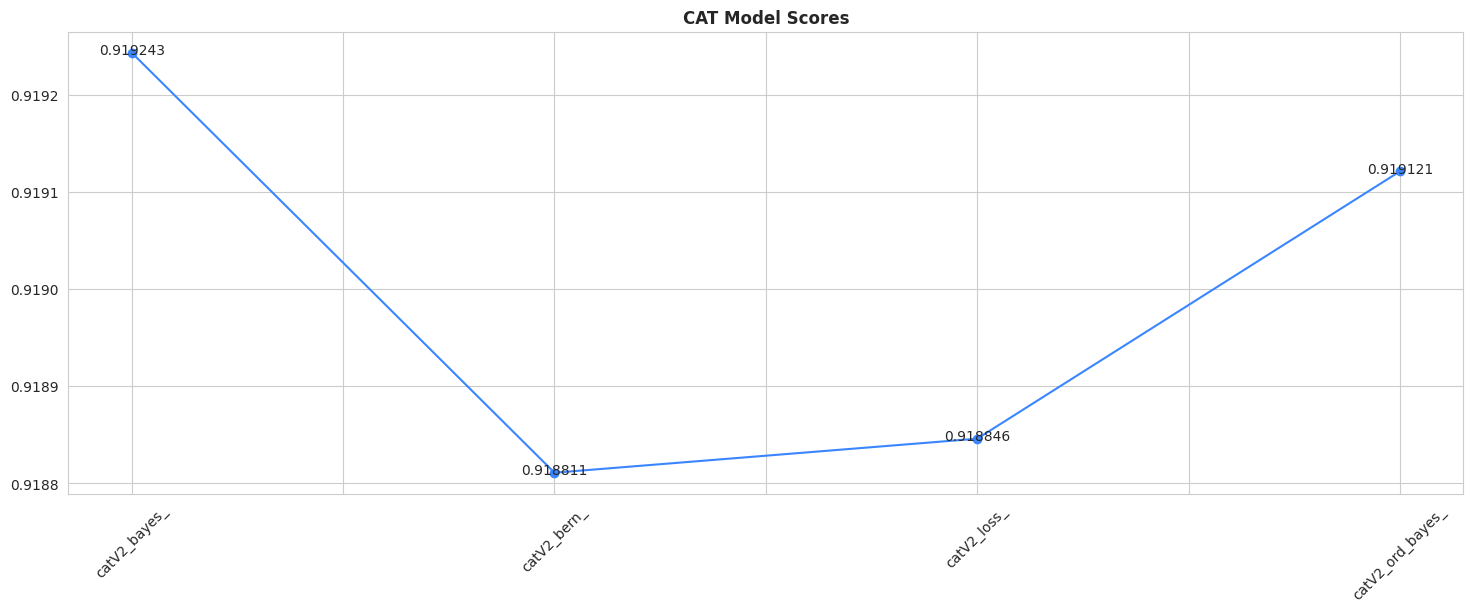

In [33]:
## -- Get Scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            # print(k, y)
            all_model_scores[k] = y

plt.figure(figsize=(18, 6))
pd.Series(all_model_scores).plot(marker='o')
plt.title('CAT Model Scores', fontweight='semibold')
for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+4e-6, score, ha='center', va='center_baseline')

plt.tick_params('x', rotation=45)
plt.show()

In [34]:
## -- Get oof outputs --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)
all_model_oof.head()

,catV2_bayes__919243,catV2_bern__918811,catV2_loss__918846,catV2_ord_bayes__919121
0,0.012582,0.006643,0.010688,0.011238
1,0.001265,0.001718,0.000817,0.001310
2,0.338032,0.326742,0.345562,0.315162
3,0.692076,0.662308,0.722320,0.715087
4,0.800101,0.802424,0.807088,0.824406


In [35]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)
all_model_test.head()

,catV2_bayes__919243,catV2_bern__918811,catV2_loss__918846,catV2_ord_bayes__919121
0,0.120243,0.132673,0.127831,0.122729
1,0.001428,0.001537,0.000468,0.001003
2,0.106497,0.102258,0.109907,0.107043
3,0.002508,0.002482,0.004176,0.002540
4,0.520983,0.511668,0.526378,0.525955


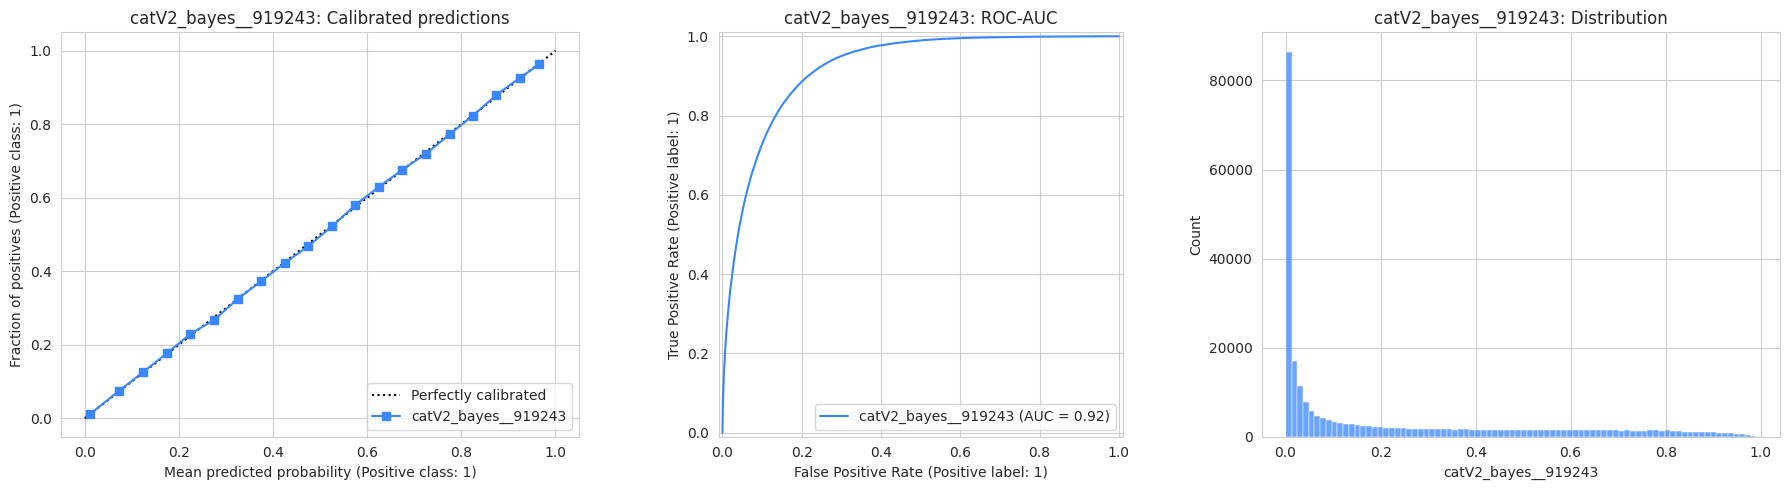

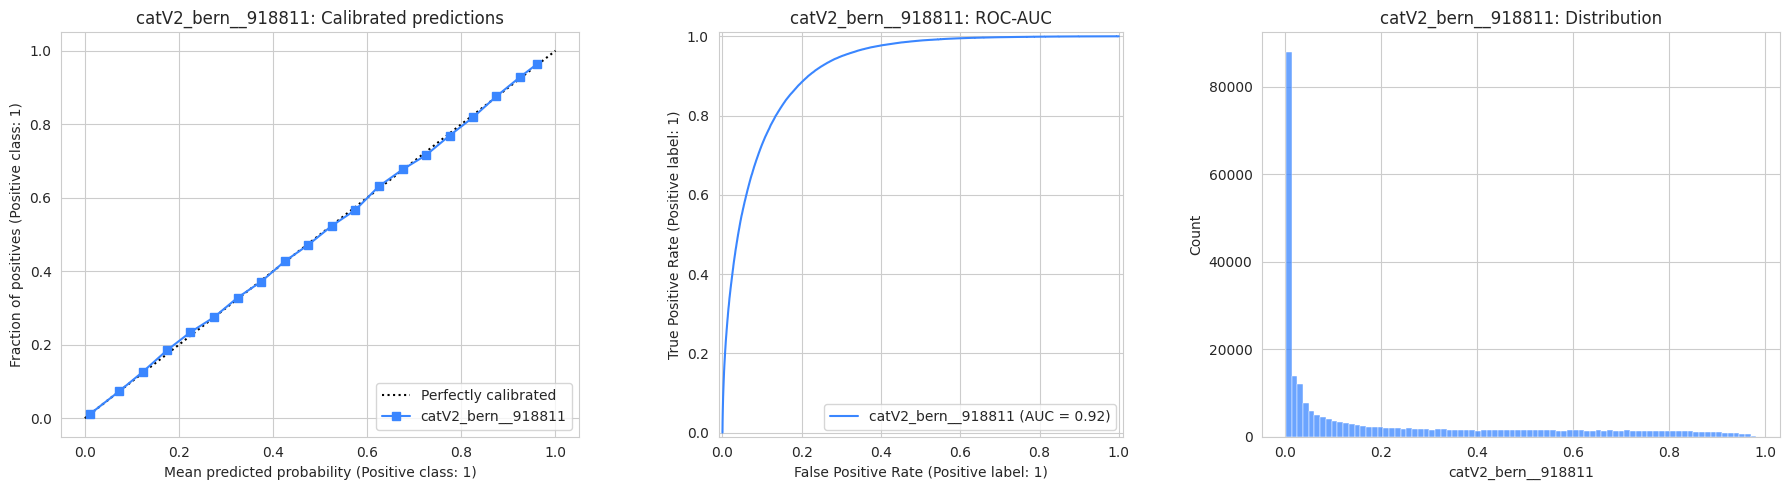

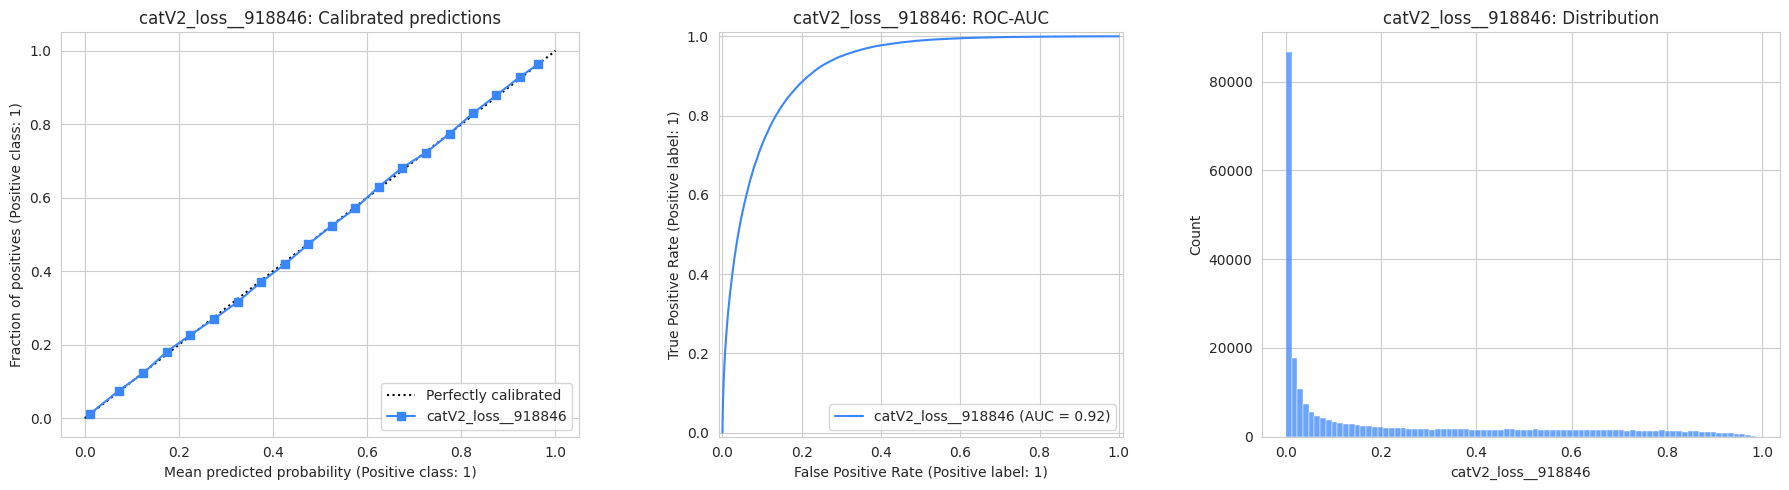

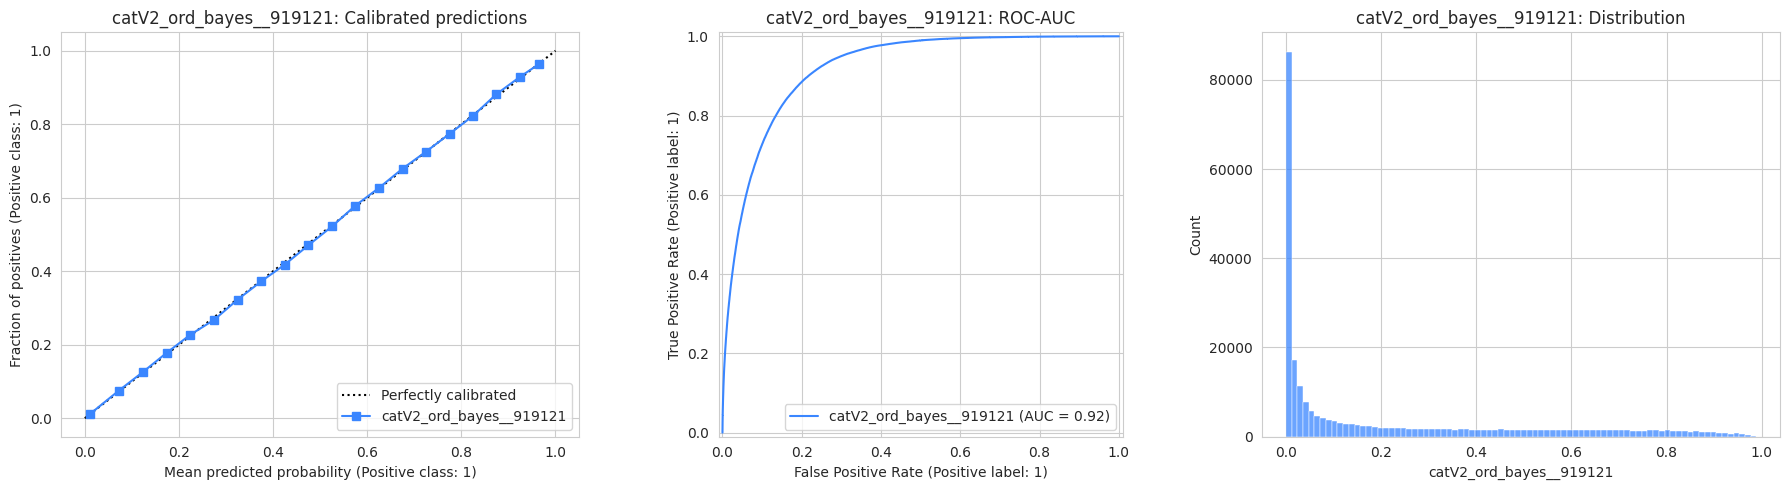

In [36]:
## -- Plot predictions --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5)) 

    CalibrationDisplay.from_predictions(train[TARGET], all_model_oof[n], n_bins=20, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")

    RocCurveDisplay.from_predictions(train[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()

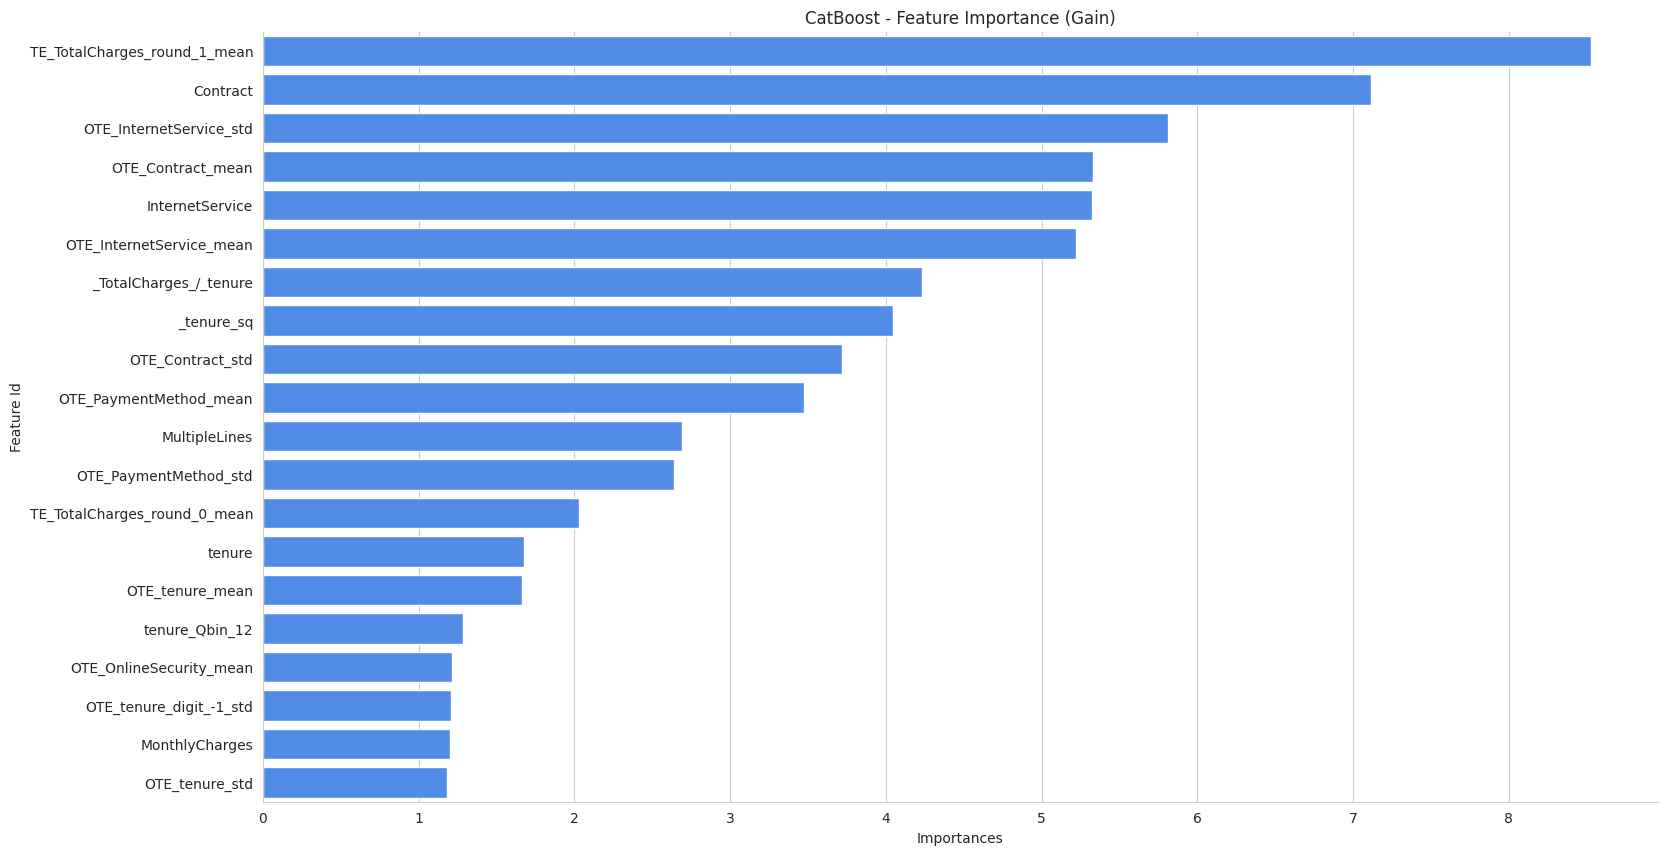

In [37]:
## -- Plot Feature Importances --
MAX = 20
get_model = all_model_predictions[list(all_model_predictions.keys())[-1]]
feature_importances = get_model['model'].get_feature_importance(prettified=True)

plt.figure(figsize=(18, 10))
ax = sns.barplot(x='Importances', y='Feature Id', data=feature_importances.head(MAX))
ax.set_title("CatBoost - Feature Importance (Gain)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# plt.tight_layout()
plt.show()